# PRIO-GRID Onset Footprint Map — `loot_onset` construction

Methodological illustration of how `loot_onset` is constructed for a single conflict.

**Definition of `loot_onset`:**
- **Geographic footprint**: all PRIO-GRID cells (0.5° × 0.5°) that contain at least one
  UCDP GED event in the first 90 days from conflict onset (`start_date`). This window
  captures the initial spatial extent of the conflict before dynamics alter its spread.
- **Resource check**: for each footprint cell, we query PRIO-GRID yearly resource layers
  (petroleum, diamonds, gems, drugs, gold) at the conflict's onset year. If any cell has
  any resource layer = 1, `loot_onset = 1`.
- `loot_onset_strict` uses only yearly layers (known discovery year ≤ onset).
- `loot_onset` additionally includes static layers (undated deposits — minor forward-contamination caveat).

**This notebook picks a random `loot_onset = 1` conflict and plots its onset PRIO-GRID
footprint over the country map, cells colored by lootable resource presence.**


In [106]:
import sys, os, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, 'functions')

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely.geometry import box

utils_path = os.path.abspath(
    os.path.join(os.getcwd(), '..', '2_data_analysis', 'utils')
)
sys.path.append(utils_path)
import plot_style

# Paths
ROOT        = '../..'
GED_PATH    = f'{ROOT}/data/input/ucdp/GEDEvent_v25_1.csv'
STATIC_PATH = f'{ROOT}/data/input/prio_grid/PRIO-GRID Static Variables - 2026-07-08.csv'
YEARLY_PATH = f'{ROOT}/data/input/prio_grid/PRIO-GRID Yearly Variables for 1989-2014 - 2026-07-08.csv'
SPELL_PATH  = f'{ROOT}/data/output/conflict_level/spell_q.csv'

# PRIO-GRID cell half-width (degrees)
CELL_HW = 0.25

# Resource layers
YEARLY_LAYERS = ['petroleum_y', 'diamsec_y', 'diamprim_y', 'gem_y',
                 'drug_y', 'goldplacer_y', 'goldvein_y', 'goldsurface_y']
STATIC_LAYERS = ['petroleum_s', 'diamsec_s', 'diamprim_s', 'gem_s',
                 'goldplacer_s', 'goldvein_s', 'goldsurface_s']

# Human-readable resource labels
RESOURCE_LABELS = {
    'petroleum_y': 'Petroleum', 'diamsec_y': 'Diamonds (sec.)',
    'diamprim_y': 'Diamonds (prim.)', 'gem_y': 'Gems',
    'drug_y': 'Drugs (coca/opium)', 'goldplacer_y': 'Gold (placer)',
    'goldvein_y': 'Gold (vein)', 'goldsurface_y': 'Gold (surface)',
    'petroleum_s': 'Petroleum (static)', 'diamsec_s': 'Diamonds sec. (static)',
    'diamprim_s': 'Diamonds prim. (static)', 'gem_s': 'Gems (static)',
    'goldplacer_s': 'Gold placer (static)', 'goldvein_s': 'Gold vein (static)',
    'goldsurface_s': 'Gold surface (static)',
}

print('Imports OK.')


Imports OK.


In [109]:
# ── Select conflict ───────────────────────────────────────────────────────────

spell_q = pd.read_csv(SPELL_PATH)
conflict_meta = spell_q.drop_duplicates('conflict_id').copy()

# Hardcode conflict; change conflict_id to try others:
#   327 Angola (34 onset cells), 13692 Afghanistan (31), 292 Peru (22),
#   389 Bosnia (21), 420 Iraq (18), 289 Colombia (12)
chosen = conflict_meta[conflict_meta['conflict_id'] == 420].iloc[0]

CONFLICT_ID = int(chosen['conflict_id'])
COUNTRY     = chosen['country']
ISOCODE     = chosen['isocode']
LOOT        = int(chosen['loot_onset'])

print(f"conflict_id : {CONFLICT_ID}")
print(f"Country     : {COUNTRY}  ({ISOCODE})")
print(f"loot_onset  : {LOOT}")


conflict_id : 420
Country     : Iraq  (IRQ)
loot_onset  : 1


In [110]:
# ── Build onset footprint ─────────────────────────────────────────────────────
# Replicates the logic inside build_onset_covariates.build_loot_onset()

ged = pd.read_csv(GED_PATH, usecols=['conflict_new_id', 'date_start', 'priogrid_gid'],
                  low_memory=False)
ged = ged.rename(columns={'conflict_new_id': 'conflict_id'})
ged['date_start'] = pd.to_datetime(ged['date_start'])

# Events for this conflict
ged_c = ged[ged['conflict_id'] == CONFLICT_ID].copy()
print(f"GED events (total):    {len(ged_c):,}")

# Onset: first 90 days from the earliest event
onset_date = ged_c['date_start'].min()
cutoff     = onset_date + pd.Timedelta(days=90)
onset_year = onset_date.year

ged_onset  = ged_c[ged_c['date_start'] <= cutoff].dropna(subset=['priogrid_gid'])
onset_gids = set(ged_onset['priogrid_gid'].astype(int).unique())

print(f"Onset date           : {onset_date.date()}  (cutoff: {cutoff.date()})")
print(f"Onset year           : {onset_year}")
print(f"GED events at onset  : {len(ged_onset):,}")
print(f"Unique PRIO-GRID cells: {len(onset_gids)}")


GED events (total):    95
Onset date           : 2003-03-17  (cutoff: 2003-06-15)
Onset year           : 2003
GED events at onset  : 95
Unique PRIO-GRID cells: 18


In [111]:
# ── Check lootable resources for each onset cell ──────────────────────────────

# 1. Yearly resources: forward-fill within gid, look up at onset_year
avail_y = [c for c in YEARLY_LAYERS if True]  # all exist in the yearly file
yearly = pd.read_csv(YEARLY_PATH, usecols=['gid','year'] + avail_y)
yearly = yearly[yearly['gid'].isin(onset_gids)].copy()
yearly = yearly.sort_values(['gid','year'])
yearly[avail_y] = yearly.groupby('gid')[avail_y].ffill()

lookup_year = min(onset_year, 2014)          # data capped at 2014
yr_at_onset = (yearly[yearly['year'] == lookup_year]
               .set_index('gid')[avail_y])

# 2. Static resources
avail_s = [c for c in STATIC_LAYERS if True]
static = pd.read_csv(STATIC_PATH, usecols=['gid','xcoord','ycoord'] + avail_s)
static_onset = static[static['gid'].isin(onset_gids)].set_index('gid')

# 3. Merge coordinates + resources
cells = (static_onset[['xcoord','ycoord'] + avail_s]
         .join(yr_at_onset, how='left'))

# 4. Loot flags per cell
for lyr in avail_y + avail_s:
    if lyr not in cells.columns:
        cells[lyr] = 0
cells[avail_y + avail_s] = cells[avail_y + avail_s].fillna(0).astype(int)

cells['has_loot_strict'] = cells[avail_y].any(axis=1).astype(int)
cells['has_loot']        = cells[avail_y + avail_s].any(axis=1).astype(int)
cells = cells.reset_index().rename(columns={'index':'gid'})

# 5. Which resources are present anywhere?
present = [l for l in avail_y + avail_s if cells[l].any()]
print(f"Cells in footprint   : {len(cells)}")
print(f"Cells with any loot  : {cells['has_loot'].sum()}  (strict: {cells['has_loot_strict'].sum()})")
print(f"Resources found      : {[RESOURCE_LABELS[l] for l in present]}")


Cells in footprint   : 18
Cells with any loot  : 16  (strict: 14)
Resources found      : ['Petroleum', 'Petroleum (static)']


In [112]:
# ── Build GeoDataFrame of cell polygons ───────────────────────────────────────

def cell_polygon(lon, lat, hw=CELL_HW):
    return box(lon - hw, lat - hw, lon + hw, lat + hw)

cells['geometry'] = [cell_polygon(r.xcoord, r.ycoord) for r in cells.itertuples()]
cells_gdf = gpd.GeoDataFrame(cells, geometry='geometry', crs='EPSG:4326')

# Primary resource label for each cell (first present layer)
def primary_resource(row):
    for lyr in avail_y + avail_s:
        if row[lyr] == 1:
            return RESOURCE_LABELS[lyr]
    return None

cells_gdf['primary_resource'] = cells_gdf.apply(primary_resource, axis=1)
cells_gdf['loot_label'] = cells_gdf['has_loot'].map({1:'Lootable resources', 0:'No resources'})

print(f"GeoDataFrame: {len(cells_gdf)} cells")
print(cells_gdf[['gid','xcoord','ycoord','has_loot','primary_resource']].head(8).to_string(index=False))


GeoDataFrame: 18 cells
   gid  xcoord  ycoord  has_loot   primary_resource
173255   47.25   30.25         1          Petroleum
173256   47.75   30.25         1          Petroleum
173976   47.75   30.75         1          Petroleum
174691   45.25   31.25         1 Petroleum (static)
174693   46.25   31.25         1          Petroleum
174695   47.25   31.25         1          Petroleum
175409   44.25   31.75         1          Petroleum
176129   44.25   32.25         1          Petroleum


In [113]:
# ── Load country boundary ─────────────────────────────────────────────────────
# Uses Natural Earth 110m countries (downloads ~500 KB on first run, then cached)

_NE_COUNTRIES_URL = (
    'https://naciscdn.org/naturalearth/110m/cultural/'
    'ne_110m_admin_0_countries.zip'
)

try:
    world = gpd.read_file(_NE_COUNTRIES_URL)
    # Filter to the conflict's country (try ISO A3 first, then name)
    country_gdf = world[world['ISO_A3'] == ISOCODE]
    if country_gdf.empty:
        country_gdf = world[world['NAME'].str.contains(COUNTRY.split()[0], case=False, na=False)]
    print(f"Country polygon: {len(country_gdf)} feature(s) found for {COUNTRY}")
except Exception as e:
    print(f"Could not load country boundary ({e}). Plotting cells only.")
    country_gdf = gpd.GeoDataFrame(geometry=[], crs='EPSG:4326')


Country polygon: 1 feature(s) found for Iraq


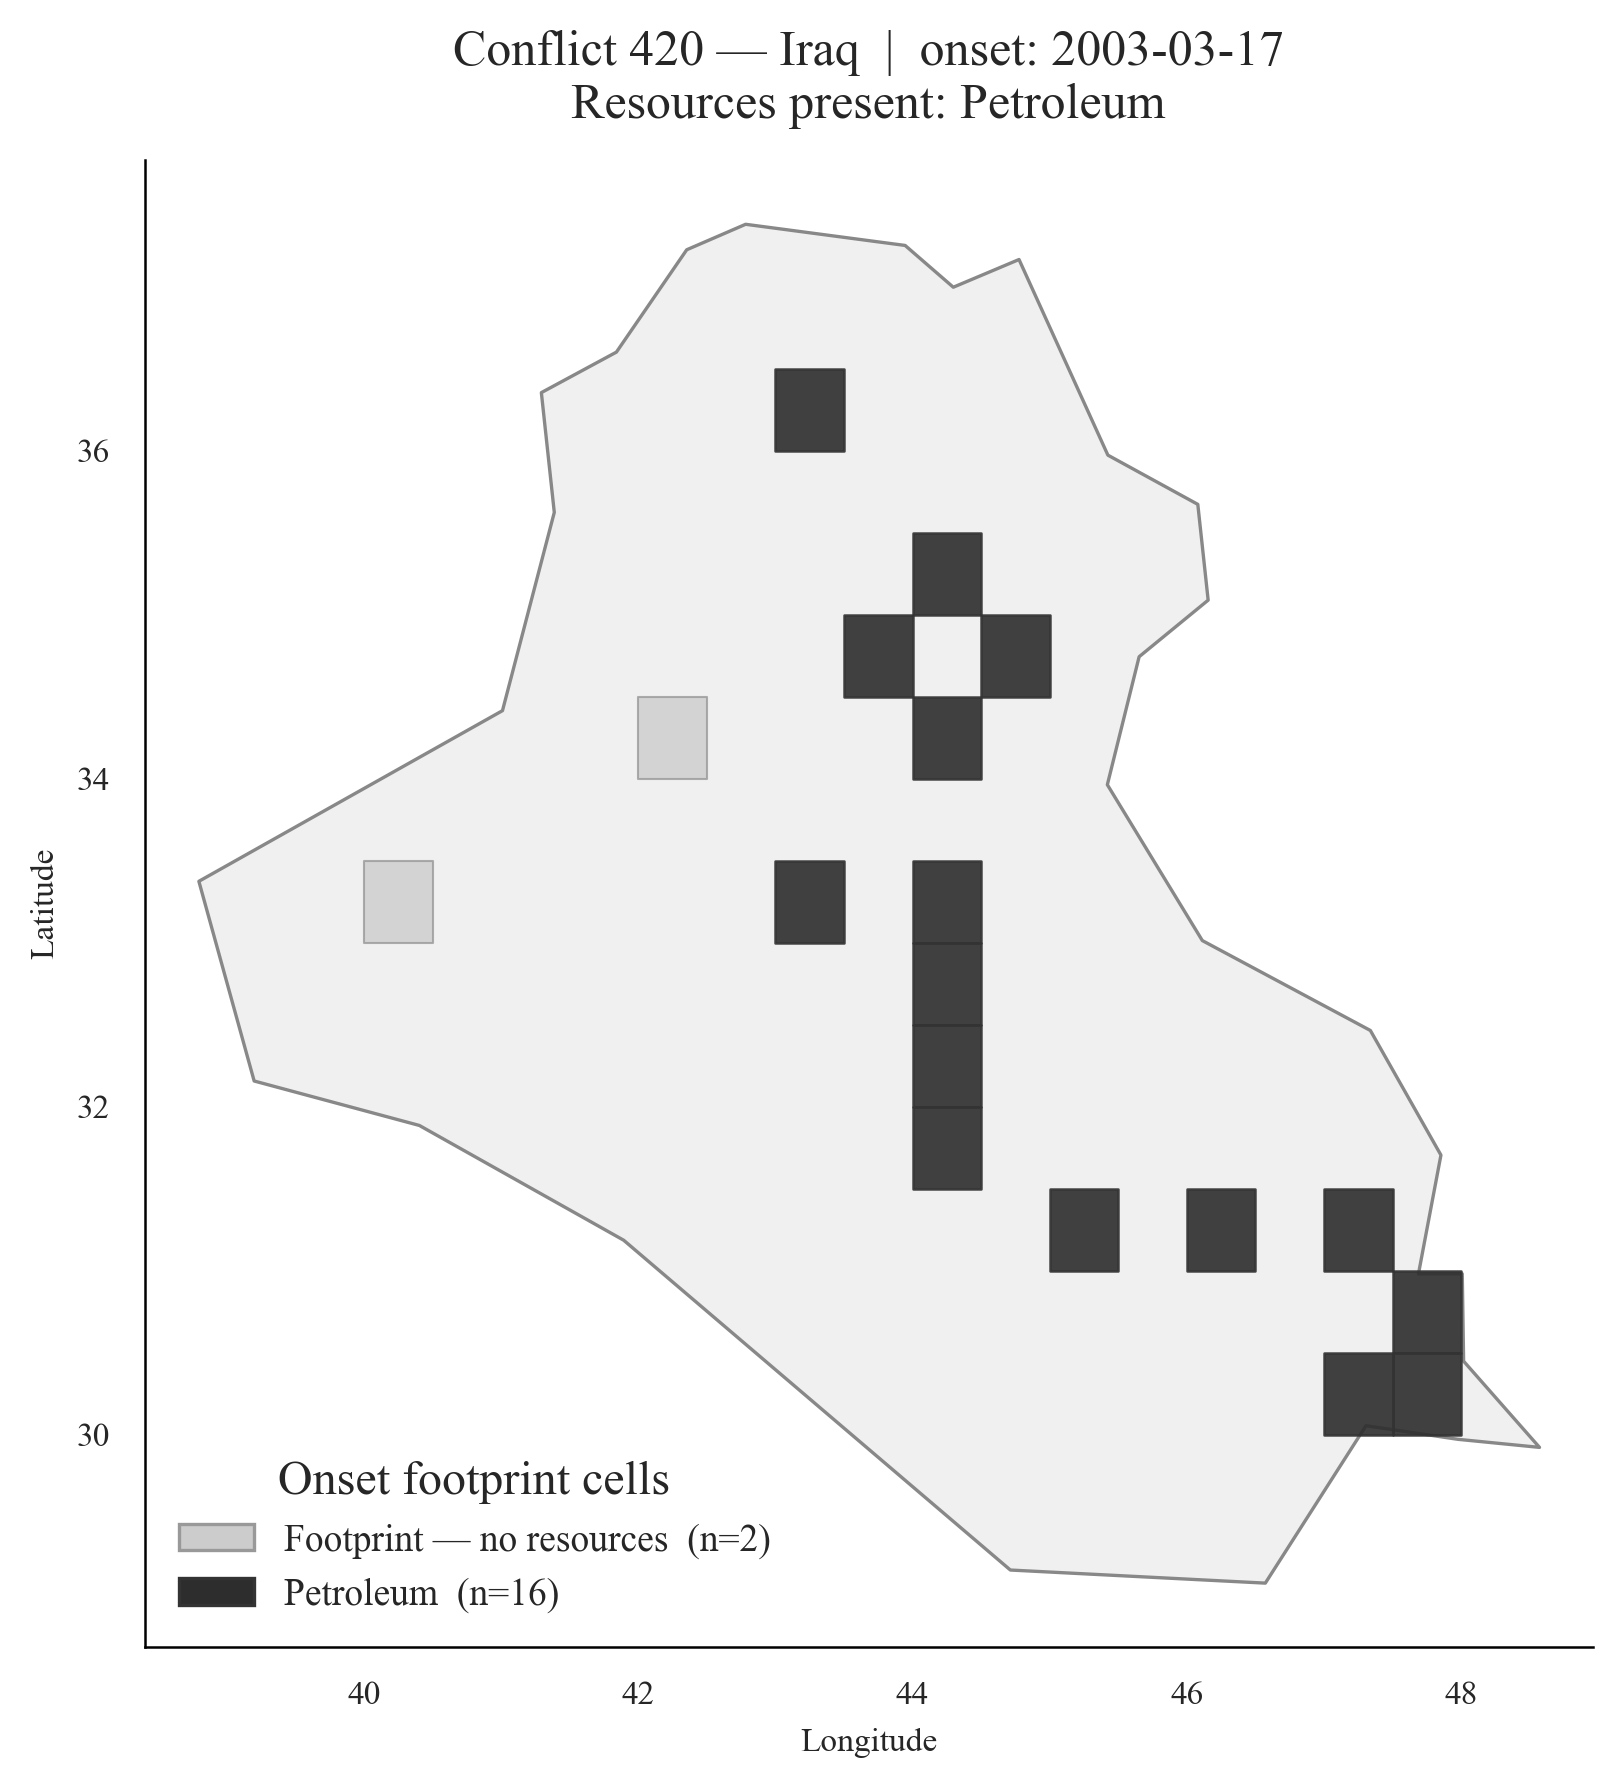

Saved: figures/loot_onset_map_conflict420.png


In [114]:
# ── Plot map ──────────────────────────────────────────────────────────────────

RESOURCE_FAMILY = {
    'Petroleum':              ('Petroleum',  '#2d2d2d'),
    'Petroleum (static)':     ('Petroleum',  '#2d2d2d'),
    'Diamonds (sec.)':        ('Diamonds',   '#5bc8e7'),
    'Diamonds sec. (static)': ('Diamonds',   '#5bc8e7'),
    'Diamonds (prim.)':       ('Diamonds',   '#5bc8e7'),
    'Diamonds prim. (static)':('Diamonds',   '#5bc8e7'),
    'Gems':                   ('Gems',       '#9141ac'),
    'Gems (static)':          ('Gems',       '#9141ac'),
    'Drugs (coca/opium)':     ('Drugs',      '#26a269'),
    'Gold (placer)':          ('Gold',       '#e5a50a'),
    'Gold placer (static)':   ('Gold',       '#e5a50a'),
    'Gold (vein)':            ('Gold',       '#e5a50a'),
    'Gold vein (static)':     ('Gold',       '#e5a50a'),
    'Gold (surface)':         ('Gold',       '#e5a50a'),
    'Gold surface (static)':  ('Gold',       '#e5a50a'),
}

cells_gdf['resource_family'] = cells_gdf['primary_resource'].map(
    lambda r: RESOURCE_FAMILY[r][0] if r in RESOURCE_FAMILY else None
)
cells_gdf['resource_color'] = cells_gdf['primary_resource'].map(
    lambda r: RESOURCE_FAMILY[r][1] if r in RESOURCE_FAMILY else None
)

# Map extent: country bounds with small padding
if not country_gdf.empty:
    cx1, cy1, cx2, cy2 = country_gdf.total_bounds
    pad = max(cx2 - cx1, cy2 - cy1) * 0.04
    extent = (cx1 - pad, cx2 + pad, cy1 - pad, cy2 + pad)
else:
    minx, miny, maxx, maxy = cells_gdf.total_bounds
    pad = max((maxx - minx), (maxy - miny)) * 0.5
    extent = (minx - pad, maxx + pad, miny - pad, maxy + pad)

# Fixed square canvas — same figsize for all conflicts so saved PNGs are identical dimensions
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

# Spine style: only bottom + left, black
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['bottom', 'left']:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_color('black')
    ax.spines[spine].set_linewidth(0.6)
ax.grid(False)

# 1. Country background
if not country_gdf.empty:
    country_gdf.plot(ax=ax, color='#f0f0f0', edgecolor='#888888',
                     linewidth=0.8, zorder=1)

# 2. Onset cells with no resources — gray
no_loot = cells_gdf[cells_gdf['has_loot'] == 0]
if not no_loot.empty:
    no_loot.plot(ax=ax, color='#cccccc', edgecolor='#999999',
                 linewidth=0.5, alpha=0.8, zorder=2)

# 3. Onset cells colored by resource family
loot_cells = cells_gdf[cells_gdf['has_loot'] == 1]
families_present = (
    cells_gdf[cells_gdf['resource_family'].notna()]
    [['resource_family', 'resource_color']]
    .drop_duplicates()
    .sort_values('resource_family')
)

for _, row in families_present.iterrows():
    subset = loot_cells[loot_cells['resource_family'] == row['resource_family']]
    subset.plot(ax=ax, color=row['resource_color'], edgecolor='#333333',
                linewidth=0.6, alpha=0.9, zorder=3)

# Legend
legend_handles = [
    mpatches.Patch(facecolor='#cccccc', edgecolor='#999999',
                   label=f'Footprint — no resources  (n={len(no_loot)})')
]
for _, row in families_present.iterrows():
    n = int((loot_cells['resource_family'] == row['resource_family']).sum())
    legend_handles.append(
        mpatches.Patch(facecolor=row['resource_color'], edgecolor='#333333',
                       label=f"{row['resource_family']}  (n={n})")
    )

ax.legend(handles=legend_handles, loc='lower left', fontsize=9,
          frameon=False, title='Onset footprint cells')

ax.set_xlim(extent[0], extent[1])
ax.set_ylim(extent[2], extent[3])
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

resources_str = ', '.join(families_present['resource_family'].tolist()) if len(families_present) else 'none'
ax.set_title(
    f'Conflict {CONFLICT_ID} — {COUNTRY}  |  onset: {onset_date.date()}\n'
    f'Resources present: {resources_str}',
    pad=10,
)

plt.tight_layout()
os.makedirs('figures', exist_ok=True)
save_path = f'figures/loot_onset_map_conflict{CONFLICT_ID}.png'
# No bbox_inches='tight': saves at exact figsize so all conflicts produce same-size PNGs
plt.savefig(save_path, dpi=180)
plt.show()
print(f'Saved: {save_path}')


---
## Note: running for multiple conflicts

To replicate the map for a different conflict, change `seed` in the cell above.
To run for all `loot_onset = 1` conflicts:

```python
for _, row in eligible.iterrows():
    CONFLICT_ID = int(row['conflict_id'])
    # ... re-run onset_cells, loot_check, build_geo, map_plot cells
```

Or pick a specific conflict by:
```python
CONFLICT_ID = 289   # Colombia / FARC
chosen = conflict_meta[conflict_meta['conflict_id'] == CONFLICT_ID].iloc[0]
```
